# 00 · Environment setup and checks

Phase 0 of the CFFM-Net pilot: before any training, prove that every moving part works on this exact machine. If something is broken, this is the cheapest place to find out.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot` (the uploaded zip) |
| **Expected runtime** | about 10 to 15 minutes |
| **Produces** | a go / no-go answer, measured scan speed and memory, and `weights/yolo26n.pt` |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


## 0. The pilot at a glance

Eleven notebooks in two phases; solid arrows carry data and checkpoints, dashed arrows metrics. The training notebooks (04, 05, 07, 08) are separate Kaggle sessions whose saved outputs 09 and 15 read.

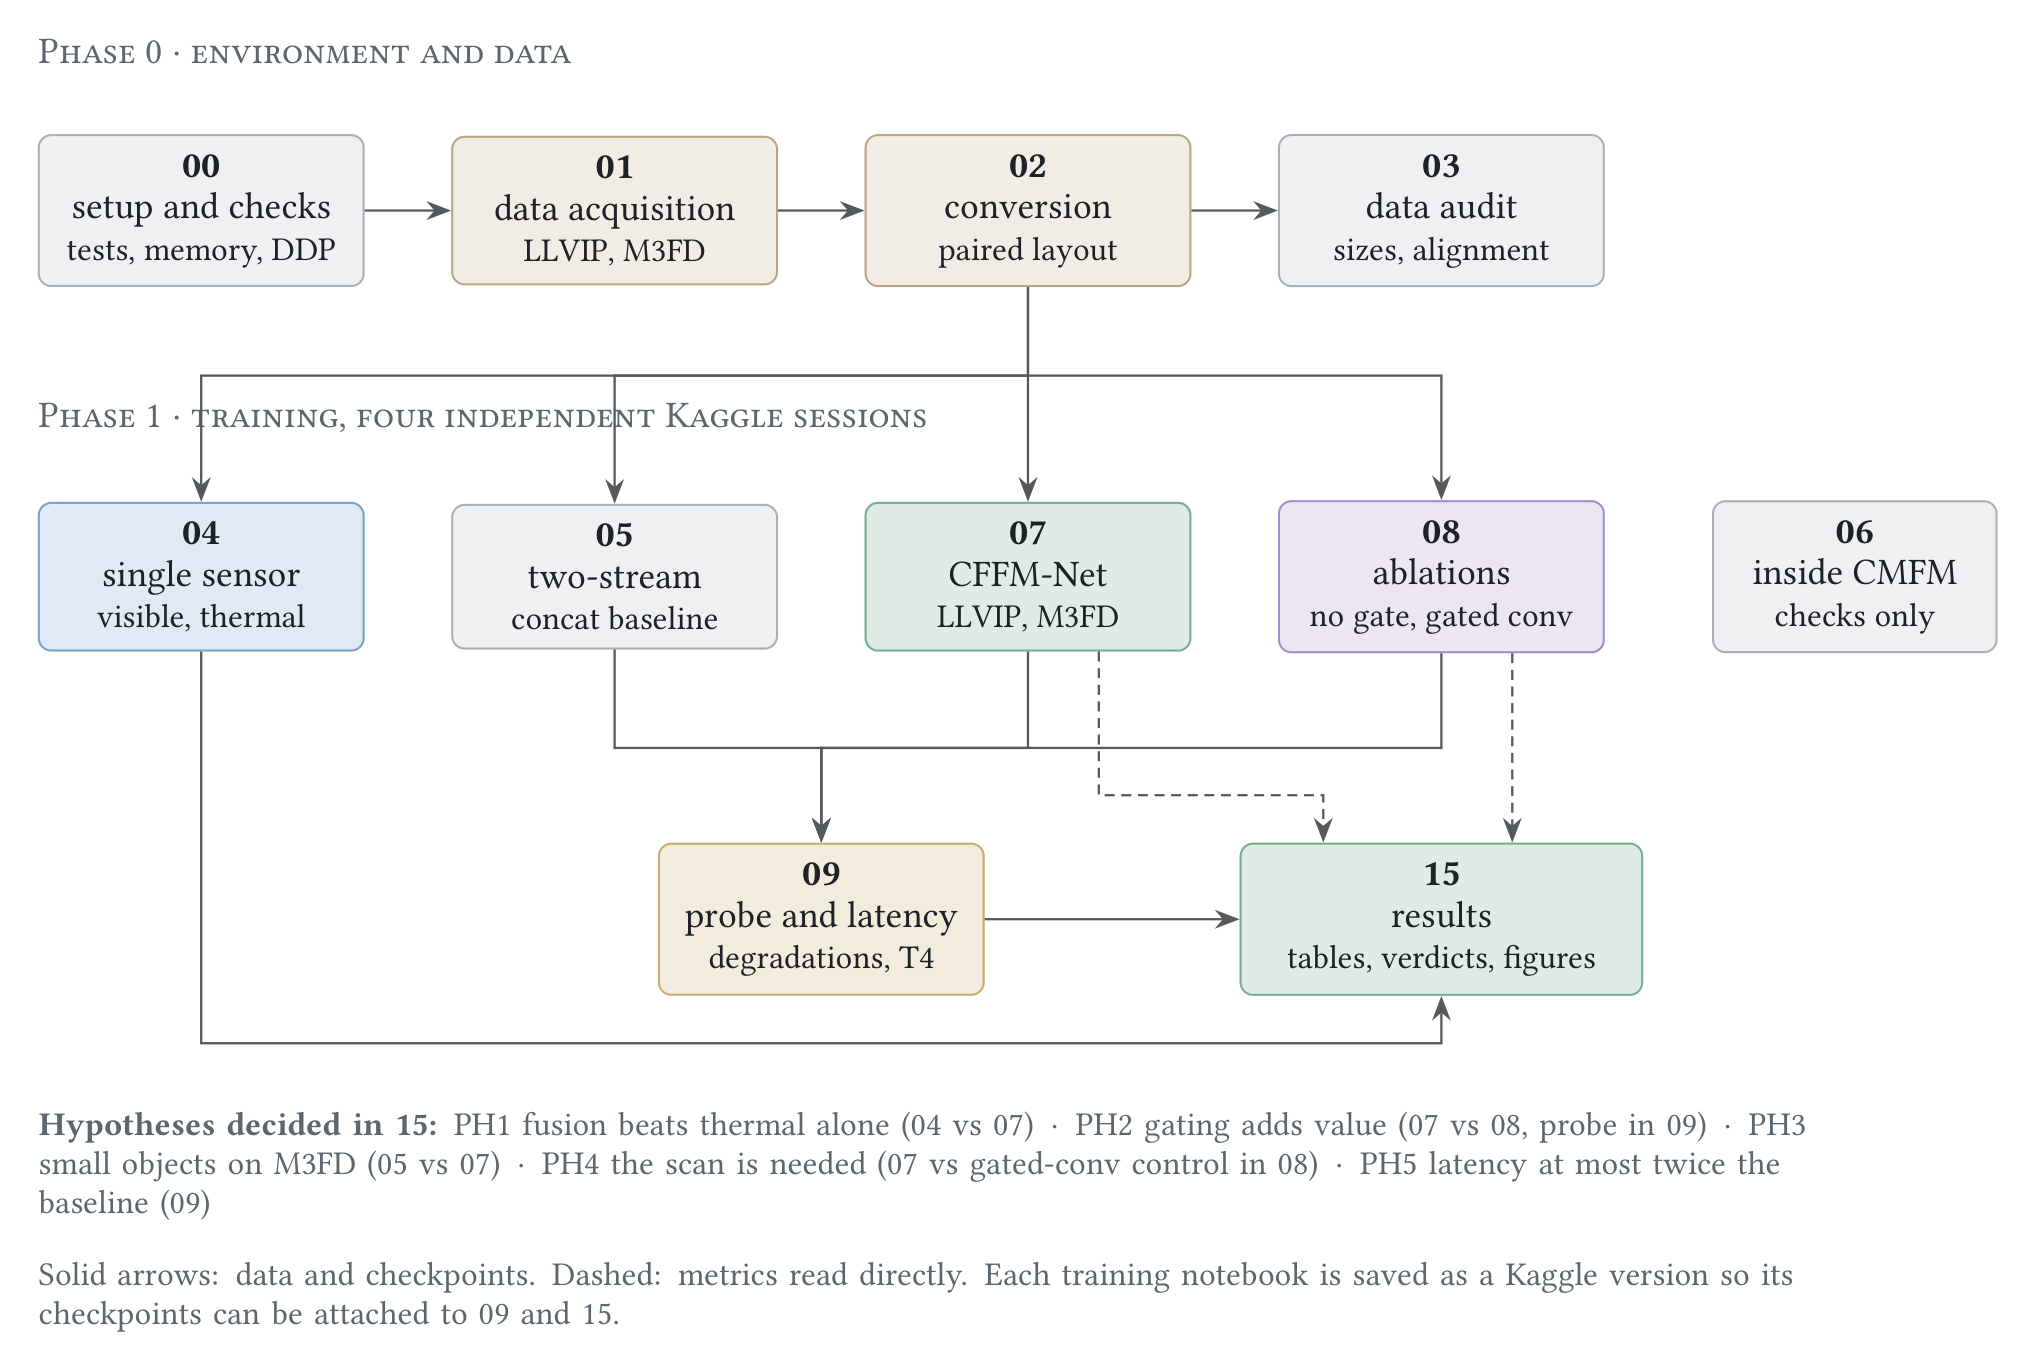

In [2]:
from IPython.display import Image, display
for name in ('fig_workflow',):
    f = env.project / "docs" / "figures" / f"{name}.png"
    if f.exists():
        display(Image(filename=str(f), width=900))
    else:
        print("missing", f)

## 1. What are we running on?

In [3]:
import json, torch
print(json.dumps(cenv.versions(), indent=2))
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {p.name}, {p.total_memory / 2**30:.1f} GB, compute capability {p.major}.{p.minor}")
assert torch.cuda.is_available(), "No GPU: set Accelerator to 'GPU T4 x2' in the notebook settings."

{
  "python": "3.12.10",
  "torch": "2.14.1+cu126",
  "cuda": "12.6",
  "ultralytics": "8.4.171",
  "mamba_ssm": false,
  "os": "Windows-11-10.0.26200-SP0"
}
GPU 0: NVIDIA GeForce RTX 4050 Laptop GPU, 6.0 GB, compute capability 8.9


## 2. COCO-pretrained YOLO26-n weights

Every model starts from these weights, so one copy goes in `weights/` and every run uses the identical file.

In [4]:
import torch
w = env.weights / "yolo26n.pt"
if not w.exists():
    torch.hub.download_url_to_file("https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26n.pt", str(w))
print(w, f"{w.stat().st_size / 1e6:.1f} MB")

C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\weights\yolo26n.pt 5.5 MB


## 3. (Optional) the fused Mamba kernel

The pilot does **not** need it: the tested pure-PyTorch scan runs anywhere, and `mamba_ssm` takes 20+ minutes
to compile and may not support the T4. Leave the flag `False` unless you want to try; if it installs, restart
the kernel and it is picked up automatically.

In [5]:
TRY_FUSED_SCAN = False
if TRY_FUSED_SCAN:
    r = subprocess.run([sys.executable, "-m", "pip", "install", "--no-build-isolation", "causal-conv1d", "mamba-ssm"],
                       capture_output=True, text=True)
    print(r.stdout[-3000:], r.stderr[-3000:])
    print("Now restart the kernel and run the notebook again from the top.")
from cffm import scan
print("mamba_ssm kernel:", scan.HAS_MAMBA_SSM, "| Triton kernel:", scan.HAS_TRITON)

mamba_ssm kernel: False | Triton kernel: False


## 4. Unit tests

Small tests, each checking one claim the method depends on. Two need the optional fused kernel and four are
an opt-in smoke run (section 7 does that run itself), so expect 6 skipped.

In [6]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "tests"], cwd=env.project, capture_output=True, text=True)
print(r.stdout[-4000:])
assert r.returncode == 0, r.stderr[-4000:]

..........................................................sssssssssssss. [ 93%]
.....                                                                    [100%]
64 passed, 13 skipped in 8.90s



## 5. How fast is the scan here?

Forward and backward at the size of CFFM-Net's biggest scan: stride 8 on a 640 crop, so **12 800 interleaved
tokens**, **256 scan channels** and **8 images per GPU**.

In [7]:
import time, torch
from cffm.scan import selective_scan

def time_scan(b=8, d=256, L=12800, n=8, groups=4, impl="torch", reps=3):
    dev = "cuda:0"
    u = torch.randn(b, d, L, device=dev, requires_grad=True)
    delta = torch.nn.functional.softplus(torch.randn(b, d, L, device=dev))
    A = -torch.exp(torch.randn(d, n, device=dev))
    B, C = torch.randn(b, groups, n, L, device=dev), torch.randn(b, groups, n, L, device=dev)
    D = torch.ones(d, device=dev)
    torch.cuda.reset_peak_memory_stats(); times = []
    for _ in range(reps + 1):
        torch.cuda.synchronize(); t = time.time()
        y = selective_scan(u, delta, A, B, C, D, impl=impl, **({"use_checkpoint": True} if impl == "torch" else {}))
        y.sum().backward(); torch.cuda.synchronize(); times.append(time.time() - t)
    return 1000 * sorted(times[1:])[len(times[1:]) // 2], torch.cuda.max_memory_allocated() / 2**30

for impl, ok in (("torch", True), ("triton", scan.HAS_TRITON), ("cuda", scan.HAS_MAMBA_SSM)):
    if ok:
        ms, gb = time_scan(impl=impl)
        print(f"{impl:6s} scan, stride-8 size, batch 8: {ms:7.1f} ms forward+backward, peak {gb:.2f} GB")

torch  scan, stride-8 size, batch 8:  1129.9 ms forward+backward, peak 2.54 GB


## 6. Do the planned batch sizes fit?

One mixed-precision forward and backward pass per model at its planned batch per GPU, measuring only memory and
step time. The last column projects one 30-epoch run on LLVIP's ~4 000 training pairs.

In [8]:
import time, torch, pandas as pd
from ultralytics.nn.tasks import DetectionModel
from cffm.model import DualStreamDetectionModel

n_gpu = max(1, torch.cuda.device_count())
def tensors(o):
    """Every tensor inside nested dicts / lists / tuples (the head's training output is nested)."""
    if torch.is_tensor(o): return [o]
    if isinstance(o, dict): o = list(o.values())
    return [t for x in o for t in tensors(x)] if isinstance(o, (list, tuple)) else []

def step(model, b, ch, hw=(640, 640), reps=3):
    m = model.to("cuda:0").train(); opt = torch.optim.SGD(m.parameters(), lr=1e-4)
    x = torch.rand(b, ch, *hw, device="cuda:0")
    torch.cuda.reset_peak_memory_stats(); times = []
    for _ in range(reps + 1):
        torch.cuda.synchronize(); t = time.time()
        with torch.autocast("cuda", dtype=torch.float16):
            loss = sum(t.float().mean() for t in tensors(m(x)) if t.requires_grad)
        loss.backward(); opt.step(); opt.zero_grad(set_to_none=True)
        torch.cuda.synchronize(); times.append(time.time() - t)
    return sorted(times[1:])[len(times[1:]) // 2], torch.cuda.max_memory_allocated() / 2**30

rows, seen = [], set()
for s in (pipeline.run_spec(plan, r["name"]) for r in plan["runs"]):
    if s["model"] in seen:
        continue
    seen.add(s["model"])
    dual = s["model"].startswith("configs/")
    model = DualStreamDetectionModel(str(env.project / s["model"]), nc=1, verbose=False) if dual \
        else DetectionModel(s["model"], nc=1, verbose=False)
    per_gpu = s["batch"] // n_gpu
    t, gb = step(model, per_gpu, 4 if dual else 3)
    hours = 4000 / s["batch"] * t * s["epochs"] / 3600 * 1.15
    rows.append({"model": Path(s["model"]).stem, "batch/GPU": per_gpu, "peak GB": round(gb, 2),
                 "step s": round(t, 3), "~hours for 30 ep on LLVIP": round(hours, 2)})
    del model; torch.cuda.empty_cache()
df = pd.DataFrame(rows); print(df.to_string(index=False))
limit = min(torch.cuda.get_device_properties(i).total_memory for i in range(n_gpu)) / 2**30
fits = (df["peak GB"] < limit - 1.0).all()
if env.platform == "kaggle":
    assert fits, "A batch is too large for this GPU: lower it in configs/pilot.yaml."
elif not fits:
    print(f"Some planned batches exceed this {limit:.0f} GB GPU; they are sized for a 15 GB T4.")

Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


                 model  batch/GPU  peak GB  step s  ~hours for 30 ep on LLVIP
               yolo26n         32     4.20   0.252                       0.30
   two-stream-concat-n         16     3.30   0.189                       0.45
            cffm-net-n         16    13.96 131.852                     315.90
     cffm-net-n-nogate         16    12.76  89.995                     215.61
      cffm-net-n-gconv         16     6.46   8.758                      20.98
       cffm-net-n-nop2         16    13.22  93.548                     224.13
two-stream-concat-p2-n         16     4.77   0.297                       0.71
         cffm-net-n-v2         16    13.22  84.406                     202.22
two-stream-concat-n-md         16     3.30   0.200                       0.48
Some planned batches exceed this 6 GB GPU; they are sized for a 15 GB T4.


## 7. The whole pipeline, end to end, on fake data and both GPUs

One epoch per model on a tiny synthetic dataset, through the real trainer, two-GPU launcher, validator and
probe. The numbers mean nothing; the point is that no step crashes.

In [9]:
from cffm.data import make_synthetic
from cffm.train import evaluate, probe, train_run

synth = make_synthetic(env.data / "synthetic", n_train=32, n_val=8, imgsz=320)
smoke = {}
for name, model, data in [("smoke_cffm", str(env.project / "configs/models/cffm-net-n.yaml"), "data_paired.yaml"),
                          ("smoke_concat", str(env.project / "configs/models/two-stream-concat-n.yaml"), "data_paired.yaml"),
                          ("smoke_visible", "yolo26n.yaml", "data_visible.yaml")]:
    best = train_run(name, model, str(synth / data), pretrained=pipeline.weights_file(env), epochs=1, imgsz=320,
                     batch=8, device=env.device, project=str(env.runs / "smoke"), workers=2, plots=False)
    smoke[name] = evaluate(best, synth / data, imgsz=320, batch=8, device=0, project=str(env.runs / "smoke_eval"))
    print(name, "ok:", {k: round(v, 3) for k, v in smoke[name].items() if k in ("mAP50(B)", "AP_s(B)")})

best = env.runs / "smoke" / "smoke_cffm" / "weights" / "best.pt"
for kind, flagged in [("clean", False), ("thermal_drop", False), ("thermal_drop", True), ("thermal_shift_8", False)]:
    m = probe(best, synth / "data_paired.yaml", kind, flagged=flagged, imgsz=320, batch=8, device=0,
              project=str(env.runs / "smoke_probe"))
    print("probe", kind, "flagged" if flagged else "", "ok")

Ultralytics 8.4.171  Python-3.12.10 torch-2.14.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed\synthetic\data_paired.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\configs\models\cffm-net-n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke_

Overriding model.yaml nc=80 with nc=1


cffm-net-n summary: 498 layers, 6,031,286 parameters, 6,031,286 gradients, 18.0 GFLOPs


Transferred 360/902 items from pretrained weights


...

 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000


 Average Recall     (AR) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000


 Average Recall     (AR) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000


Results saved to C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs\smoke_probe\smoke_cffm_thermal_shift_8


probe thermal_shift_8  ok


## 8. Verdict

If every cell above ran without an error, the environment is ready. Clean up the smoke runs, then continue with
**01 · Data acquisition**.

In [10]:
shutil.rmtree(env.runs / "smoke", ignore_errors=True)
for d in ("smoke_eval", "smoke_probe"):
    shutil.rmtree(env.runs / d, ignore_errors=True)
shutil.rmtree(env.data / "synthetic", ignore_errors=True)
print("Phase 0 checks passed. Next: 01_data_acquisition.ipynb")

Phase 0 checks passed. Next: 01_data_acquisition.ipynb
